In [1]:
# Generate data/imagenet_classes.txt so semantic_taxonomy.py works without torchvision.
# This uses the same class list that clip_labeler uses, ensuring consistency.
from torchvision.models import ResNet50_Weights
from pathlib import Path
classes = ResNet50_Weights.IMAGENET1K_V1.meta['categories']
out = Path('../data/imagenet_classes.txt')
out.write_text(''.join(classes), encoding='utf-8')
print(f'Saved {len(classes)} ImageNet class names to {out}')

Saved 1000 ImageNet class names to ..\data\imagenet_classes.txt


In [2]:
import sys; sys.path.insert(0, '..')
import torch
import matplotlib.pyplot as plt
import numpy as np
from src.semantic_taxonomy import assign_category, get_category_distribution, CATEGORIES

labels4  = torch.load('../checkpoints/labels_layer4.pt',  map_location='cpu', weights_only=False)
labels8  = torch.load('../checkpoints/labels_layer8.pt',  map_location='cpu', weights_only=False)
labels12 = torch.load('../checkpoints/labels_layer12.pt', map_location='cpu', weights_only=False)
print(f'Loaded: {len(labels4["labels"])} features per layer')

Loaded: 3072 features per layer


In [3]:
cats4  = [assign_category(l) for l in labels4['labels']]
cats8  = [assign_category(l) for l in labels8['labels']]
cats12 = [assign_category(l) for l in labels12['labels']]

torch.save({'layer4': cats4, 'layer8': cats8, 'layer12': cats12},
           '../checkpoints/semantic_categories.pt')

n_labeled = len(cats4)  # all SAE features labeled (3072 after full NB03 run)
print(f'Labeled {n_labeled} features per layer.')
print()
print(f'{"Category":<14} {"Layer 4":>10} {"Layer 8":>10} {"Layer 12":>10}')
print('-' * 48)
d4, d8, d12 = [get_category_distribution(labels) for labels in [labels4['labels'], labels8['labels'], labels12['labels']]]
for cat in CATEGORIES:
    print(f'{cat:<14} {d4[cat]:>10} {d8[cat]:>10} {d12[cat]:>10}')

Labeled 3072 features per layer.

Category          Layer 4    Layer 8   Layer 12
------------------------------------------------
background           2231       1404       1298
texture               330        451        382
color                   0          0          0
object_part            55        104         98
scene                  31         74         60
object                425       1039       1234


Interpretable features (excl. blurred background):
  Layer 4:  868/3072 (28.3%)
  Layer 8:  1689/3072 (55.0%)
  Layer 12: 1792/3072 (58.3%)


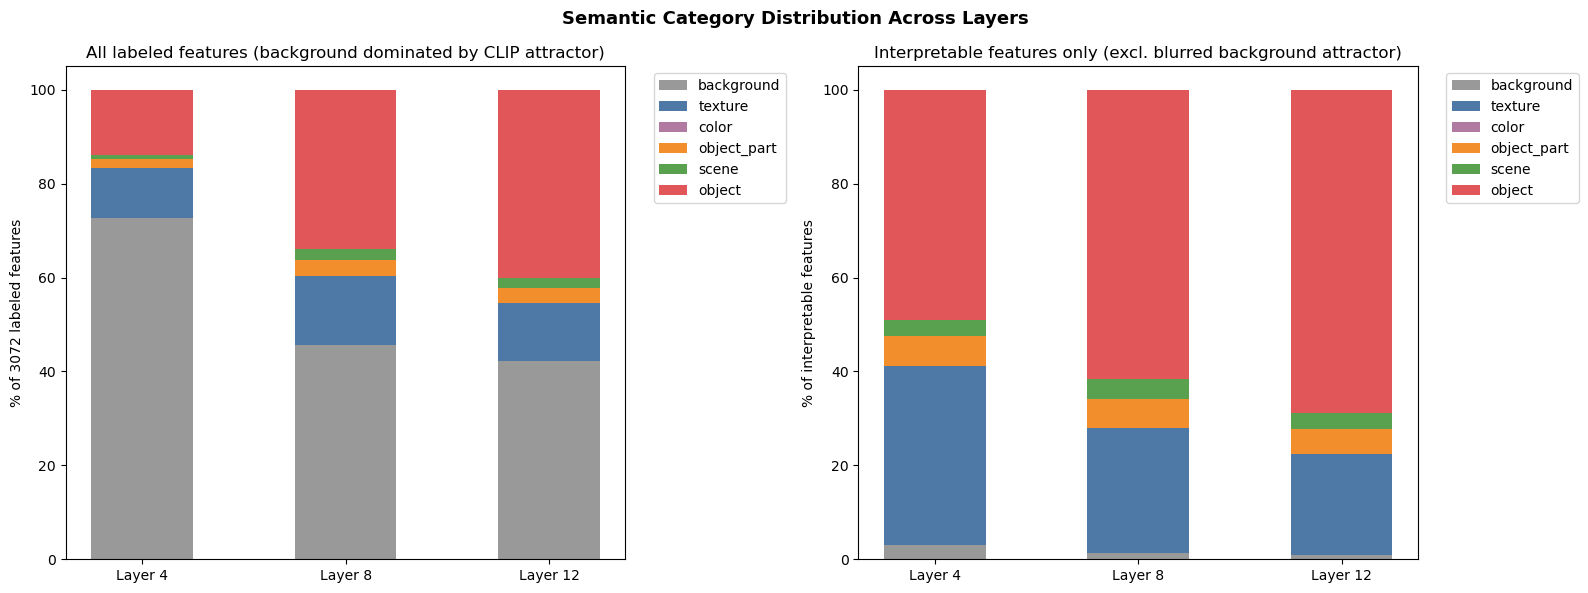

In [4]:
dists = [d4, d8, d12]
layer_names = ['Layer 4', 'Layer 8', 'Layer 12']
cat_colors = {
    'background':  '#999999',
    'texture':     '#4e79a7',
    'color':       '#b07aa1',
    'object_part': '#f28e2b',
    'scene':       '#59a14f',
    'object':      '#e15759',
}

# Filtered: exclude 'blurred background' (CLIP attractor) to show interpretable features only.
# cats*_filt contains category strings, so count directly — do NOT pass to get_category_distribution
# (which calls assign_category and expects raw label strings, not category names).
cats4_filt  = [c for l, c in zip(labels4['labels'],  cats4)  if l != 'blurred background']
cats8_filt  = [c for l, c in zip(labels8['labels'],  cats8)  if l != 'blurred background']
cats12_filt = [c for l, c in zip(labels12['labels'], cats12) if l != 'blurred background']
nf4, nf8, nf12 = len(cats4_filt), len(cats8_filt), len(cats12_filt)
df4  = {cat: cats4_filt.count(cat)  for cat in CATEGORIES}
df8  = {cat: cats8_filt.count(cat)  for cat in CATEGORIES}
df12 = {cat: cats12_filt.count(cat) for cat in CATEGORIES}
dists_filt = [df4, df8, df12]
ns_filt    = [nf4, nf8, nf12]

print(f'Interpretable features (excl. blurred background):')
print(f'  Layer 4:  {nf4}/{n_labeled} ({nf4/n_labeled*100:.1f}%)')
print(f'  Layer 8:  {nf8}/{n_labeled} ({nf8/n_labeled*100:.1f}%)')
print(f'  Layer 12: {nf12}/{n_labeled} ({nf12/n_labeled*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: raw distribution (all labeled features)
ax = axes[0]
bottoms = np.zeros(3)
for cat in CATEGORIES:
    counts = np.array([d[cat] / n_labeled * 100 for d in dists])
    ax.bar(layer_names, counts, bottom=bottoms,
           label=cat, color=cat_colors[cat], width=0.5)
    bottoms += counts
ax.set_ylabel(f'% of {n_labeled} labeled features')
ax.set_title('All labeled features (background dominated by CLIP attractor)')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

# Right panel: interpretable features only (excl. blurred background)
ax = axes[1]
bottoms = np.zeros(3)
for cat in CATEGORIES:
    counts = np.array([d[cat] / ns_filt[i] * 100 for i, d in enumerate(dists_filt)])
    ax.bar(layer_names, counts, bottom=bottoms,
           label=cat, color=cat_colors[cat], width=0.5)
    bottoms += counts
ax.set_ylabel('% of interpretable features')
ax.set_title('Interpretable features only (excl. blurred background attractor)')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

plt.suptitle('Semantic Category Distribution Across Layers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../checkpoints/semantic_taxonomy_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
def entropy(dist: dict, n_total: int) -> float:
    import math
    return -sum((v / n_total) * math.log2(v / n_total + 1e-9)
                for v in dist.values() if v > 0)

print(f'CLIP Interpretability Rate (% features CLIP can label meaningfully):')
print(f'  Layer 4:  {nf4/n_labeled*100:.1f}%  ({nf4}/{n_labeled} features)')
print(f'  Layer 8:  {nf8/n_labeled*100:.1f}%  ({nf8}/{n_labeled} features)')
print(f'  Layer 12: {nf12/n_labeled*100:.1f}%  ({nf12}/{n_labeled} features)')
print()

print(f"{'Layer':<12} {'Entropy (all)':>15} {'Entropy (interp.)':>20}")
print('-' * 50)
for name, dist, dist_f, nf in [
        ('Layer 4',  d4,  df4,  nf4),
        ('Layer 8',  d8,  df8,  nf8),
        ('Layer 12', d12, df12, nf12)]:
    h_all  = entropy(dist,   n_labeled)
    h_filt = entropy(dist_f, nf)
    print(f'{name:<12} {h_all:>15.3f} {h_filt:>20.3f}')
print('(Higher entropy = more diverse feature types)')

CLIP Interpretability Rate (% features CLIP can label meaningfully):
  Layer 4:  28.3%  (868/3072 features)
  Layer 8:  55.0%  (1689/3072 features)
  Layer 12: 58.3%  (1792/3072 features)

Layer          Entropy (all)    Entropy (interp.)
--------------------------------------------------
Layer 4                1.247                1.615
Layer 8                1.746                1.464
Layer 12               1.697                1.306
(Higher entropy = more diverse feature types)
